In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import CNN
import torch
import torch.nn as nn

In [2]:
# 导入训练好的模型文件
model = CNN.CNN()
model.load_state_dict(torch.load('/home/gracchus/code/UCAS-Deep-Learning-2026Spring/Lab1/model/cnn_mnist.pth'))

<All keys matched successfully>

In [3]:
# 利用测试集进行评估，并绘制混淆矩阵、ROC曲线、准确率召回率F1分数等图表
# 数据为MNIST测试集，可以使用torchvision.datasets.MNIST加载测试集数据
from torchvision import datasets, transforms
transform = transforms.Compose([transforms.ToTensor()])
test_dataset = datasets.MNIST(root='/home/gracchus/code/UCAS-Deep-Learning-2026Spring/Data/', train=False, transform=transform, download=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

In [4]:
# 开始评估，用GPU进行推理
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

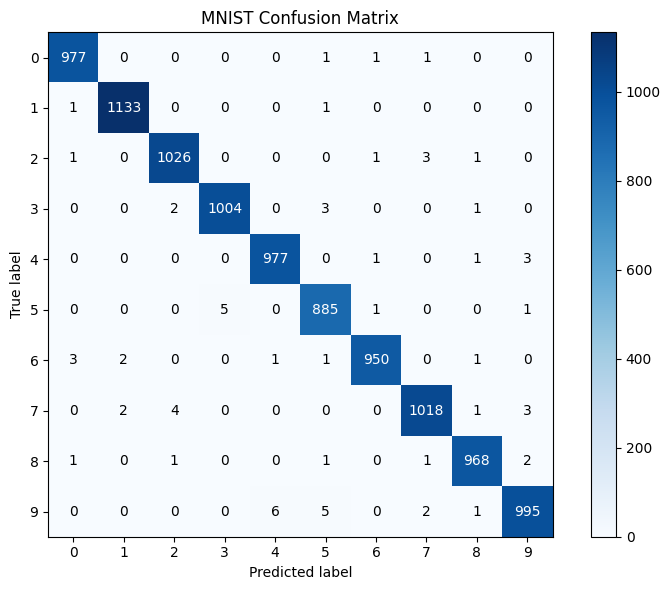

In [15]:
# 根据测试集预测结果绘制混淆矩阵（使用matplotlib默认风格）
labels = list(range(10))
confusion = pd.crosstab(
    pd.Series(all_labels, name='True label'),
    pd.Series(all_preds, name='Predicted label')
).reindex(index=labels, columns=labels, fill_value=0)

plt.style.use('default')
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(confusion.to_numpy(), interpolation='nearest', cmap='Blues')
fig.colorbar(im, ax=ax)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('MNIST Confusion Matrix')

threshold = confusion.to_numpy().max() / 2
for i in range(len(labels)):
    for j in range(len(labels)):
        value = confusion.iloc[i, j]
        ax.text(j, i, value, ha='center', va='center', color='white' if value > threshold else 'black')

plt.tight_layout()
plt.savefig('/home/gracchus/code/UCAS-Deep-Learning-2026Spring/Lab1/Figure/confusion_matrix.png', dpi=300)
plt.show()


In [16]:
# 根据混淆矩阵计算每一类的precision、recall，并找出最常见的错误类型
cm = confusion.to_numpy()
per_class_metrics = pd.DataFrame({
    'digit': labels,
    'precision': np.diag(cm) / cm.sum(axis=0),
    'recall': np.diag(cm) / cm.sum(axis=1),
})

errors = cm.copy()
np.fill_diagonal(errors, 0)
error_pairs = []
for true_label in labels:
    for pred_label in labels:
        if true_label != pred_label and errors[true_label, pred_label] > 0:
            error_pairs.append((true_label, pred_label, errors[true_label, pred_label]))
error_pairs = sorted(error_pairs, key=lambda item: item[2], reverse=True)

print('Per-class precision and recall:')
display(per_class_metrics)
print('Most common error pairs (true -> pred):')
display(pd.DataFrame(error_pairs[:10], columns=['true_label', 'pred_label', 'count']))


Per-class precision and recall:


,digit,precision,recall
0,0,0.993896,0.996939
1,1,0.996482,0.998238
2,2,0.993224,0.994186
3,3,0.995045,0.994059
4,4,0.992886,0.994908
5,5,0.986622,0.992152
6,6,0.995807,0.991649
7,7,0.993171,0.990272
8,8,0.993840,0.993840
9,9,0.991036,0.986125


Most common error pairs (true -> pred):


,true_label,pred_label,count
0,9,4,6
1,5,3,5
2,9,5,5
3,7,2,4
4,2,7,3
5,3,5,3
6,4,9,3
7,6,0,3
8,7,9,3
9,3,2,2


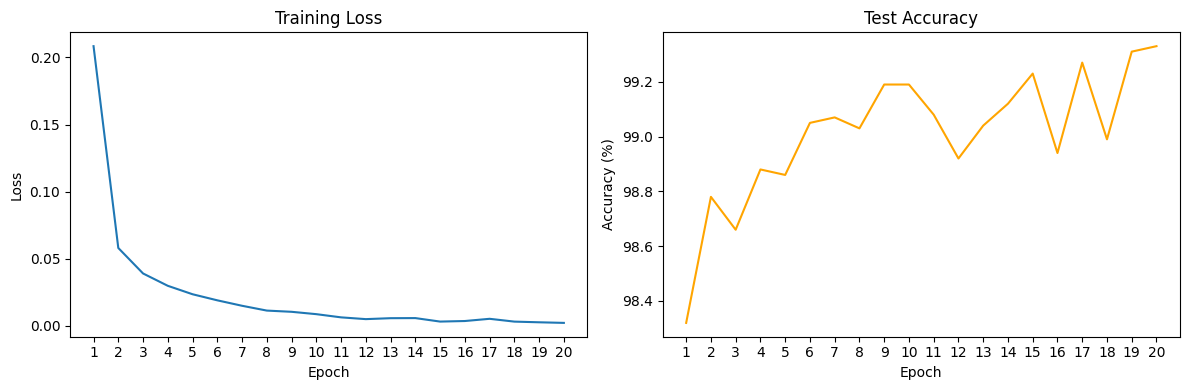

In [17]:
# 读取训练日志csv文件，绘制训练损失和测试准确率的变化曲线
log_df = pd.read_csv('/home/gracchus/code/UCAS-Deep-Learning-2026Spring/Lab1/logs/train_log.csv')
plt.style.use('default')  # 使用默认样式

plt.figure(figsize=(12, 4))

# 训练损失
plt.subplot(1, 2, 1)
plt.plot(log_df['epoch'], log_df['train_loss'], label='Train Loss')
plt.xticks(log_df['epoch'])  # 横轴使用整数
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
#plt.legend()

# 测试准确率（百分比）
plt.subplot(1, 2, 2)
plt.plot(log_df['epoch'], log_df['test_acc'] * 100, label='Test Accuracy', color='orange')  # 转换为百分比
plt.xticks(log_df['epoch'])  # 横轴使用整数
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Test Accuracy')
#plt.legend()

plt.tight_layout()
#plt.show()
plt.savefig('/home/gracchus/code/UCAS-Deep-Learning-2026Spring/Lab1/Figure/train_log.png')